## Libraries

In [71]:
import numpy as np
import matplotlib.pyplot as plt

## Optimizers

### Gradient Descent - 1D

In [72]:
def func(x):
  return x**2

def func_grad(x):
  return 2*x

In [73]:
def gradient_descent(lr, func_grad):
  x = -10
  x_values = [x]
  
  for i in range(10):
    x -= lr*func_grad(x)
    x_values.append(x)
    
  print("iteration 10, x: %s"%x)
  return x_values

In [74]:
def search_path(x_vals, func):
  x_line = np.arange(-15, 15, 0.01)
  
  plt.plot(x_line, [func(x) for x in x_line])
  plt.plot(x_vals, [func(x) for x in x_vals], "ro-")

iteration 10, x: -0.060466176000000066


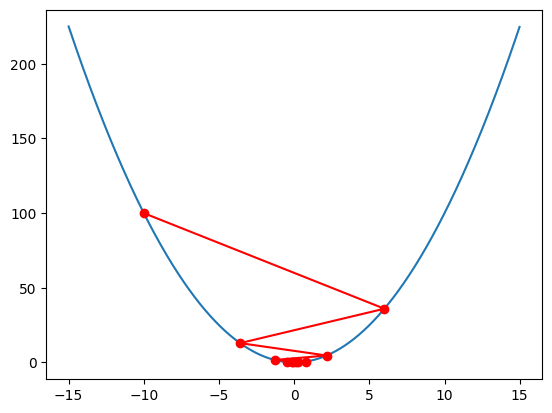

In [75]:
x_values = gradient_descent(0.8, func_grad)
search_path(x_values, func)

### Gradient Descent - 2D

In [76]:
def func(x1, x2):
    return x1**2 + 2 * x2**2

def func_grad(x1, x2):
    return (2*x1, 4*x2)

In [77]:
class Optimizers:
    def __init__(self, lr_schedule, rate=0.01):
        self.lr_schedule = self.lr(lr_schedule, rate)

    def lr(self, lr_schedule, rate):
        if lr_schedule == "constant":
            return self.constant_lr(rate)

    def constant_lr(self, rate):
        return rate

    # 1- Gradient Descent
    def gradient_descent(self, x1, x2, t1, t2, func_grad):
        gr_x1, gr_x2 = func_grad(x1, x2)
        return x1 - self.lr_schedule*gr_x1, x2 - self.lr_schedule*gr_x2, 0, 0
    
    # 2- SGD
    def stochastic_gradient_descent(self, x1, x2, t1, t2, func_grad):
        gr_x1, gr_x2 = func_grad(x1, x2)
        gr_x1 += np.random.normal(0, 1)
        gr_x2 += np.random.normal(0, 1)
        return x1 - self.lr_schedule*gr_x1, x2 - self.lr_schedule*gr_x2, 0, 0
    
    # 3- Gradient Descent with Momentum
    def gradient_descent_with_momentum(self, x1, x2, v1, v2, func_grad):
        alpha = 0.9
        gr_x1, gr_x2 = func_grad(x1, x2)
        v1 = alpha*v1 - self.lr_schedule*gr_x1
        v2 = alpha*v2 - self.lr_schedule*gr_x2
        return x1 + v1, x2 + v2, v1, v2
    
    # 4- Nesterov Gradient Descent with Momentum
    def nesterov_gradient_descent_with_momentum(self, x1, x2, v1, v2, func_grad):
        alpha=0.9
        x1 += alpha*v1
        x2 += alpha*v2
        gr_x1, gr_x2 = func_grad(x1, x2)
        v1 = alpha*v1 - self.lr_schedule*gr_x1
        v2 = alpha*v2 - self.lr_schedule*gr_x2
        return x1 + v1, x2 + v2, v1, v2
    
    # 5- Adagrad
    def ada_grad(self, x1, x2, r1, r2, func_grad):
        delta = 1e-7
        gr_x1, gr_x2 = func_grad(x1, x2)
        r1 += gr_x1**2
        r2 += gr_x2**2
        x1 -= self.lr_schedule/(delta + np.sqrt(r1))*gr_x1
        x2 -= self.lr_schedule/(delta + np.sqrt(r2))*gr_x2
        return x1, x2, r1, r2
    
    # 6- RMSProp
    def rmsprop(self, x1, x2, r1, r2, func_grad):
        delta = 1e-7
        rho = 0.9
        gr_x1, gr_x2 = func_grad(x1, x2)
        r1 = r1*rho + (1-rho)*gr_x1**2
        r2 = r2*rho + (1-rho)*gr_x2
        x1 -= self.lr_schedule/np.sqrt(delta+r1)*gr_x1
        x2 -= self.lr_schedule/np.sqrt(delta+r1)*gr_x2
        return x1, x2, r1, r2
    
    
    # 7- RMSProp with Nesterov
    def rmsprop_with_nesterov(self, x1, x2, r1, r2, v1, v2, func_grad):
        delta = 1e-7
        rho = 0.9
        mu = 0.9

        # 1. Lookahead step
        lookahead_x1 = x1 - mu * v1
        lookahead_x2 = x2 - mu * v2

        # 2. Compute gradient at lookahead position
        gr_x1, gr_x2 = func_grad(lookahead_x1, lookahead_x2)

        # 3. RMSProp-style scaling
        r1 = rho * r1 + (1 - rho) * gr_x1**2
        r2 = rho * r2 + (1 - rho) * gr_x2**2

        # 4. Scaled gradients
        scaled_gr_x1 = gr_x1 / (np.sqrt(r1 + delta))
        scaled_gr_x2 = gr_x2 / (np.sqrt(r2 + delta))

        # 5. Update velocities
        v1 = mu * v1 + self.lr_schedule * scaled_gr_x1
        v2 = mu * v2 + self.lr_schedule * scaled_gr_x2

        # 6. Update parameters
        x1 -= v1
        x2 -= v2

        return x1, x2, r1, r2, v1, v2
    
    
    # 8- Adam
    def adam(self, x1, x2, s1, s2, r1, r2, t, func_grad):
        delta, rho1, rho2 = 1e-8, 0.9, 0.999
        gr_x1, gr_x2 = func_grad(x1, x2)
        
        s1 = rho1*s1 + (1-rho1)*gr_x1
        s2 = rho1*s2 + (1-rho1)*gr_x2
        
        r1 = rho2*r1 + (1-rho2)*gr_x1**2
        r2 = rho2*r2 + (1-rho2)*gr_x2**2
        
        shat1 = s1/(1-rho1**(t+1))
        shat2 = s2/(1-rho1**(t+1))
        
        rhat1 = r1/(1-rho2**(t+1))
        rhat2 = r2/(1-rho2**(t+1))
        
        x1 -= self.lr_schedule*shat1/(np.sqrt(rhat1)+delta)
        x2 -= self.lr_schedule*shat2/(np.sqrt(rhat2)+delta)
        
        return x1, x2, s1, s2, r1, r2

### Search

#### 1- Gradient Descent

In [78]:
def search(optimizer, func_grad, iteration=20):
    x1, x2, t1, t2 = -5, -2, 0, 0
    x_iterations = [(x1, x2)]
  
    for i in range(iteration):
        x1, x2, t1, t2 = optimizer(x1, x2, t1, t2, func_grad)
        x_iterations.append((x1, x2))
    
    print("epoch {}, x1:{}, x2:{}".format(i+1, x1, x2))
    return x_iterations

#### 2- RMSProp with Nestrov 

In [79]:
def search_rmsprop(optimizer, func_grad, iteration=50):
    x1, x2, t1, t2, v1, v2 = -5, -2, 0, 0, 0, 0
    x_iterations = [(x1, x2)]

    for i in range(iteration):
        x1, x2, t1, t2, v1, v2 = optimizer(x1, x2, t1, t2, v1, v2, func_grad)
        x_iterations.append((x1, x2))

    print("epoch {}, x1:{}, x2:{}".format(i+1, x1, x2))
    return x_iterations

#### 3- Adam

In [80]:
def search_adam(optimizer_adam, func_grad, iterations=20):
    x1, x2, s1, s2, r1, r2 = -5, -2, 0, 0, 0, 0
    x_iterations = [(x1, x2)]
    
    for t in range(iterations):
        x1, x2, s1, s2, r1, r2 = optimizer_adam(x1, x2, s1, s2, r1, r2, t, func_grad)
        x_iterations.append((x1, x2))
        
    print("epoch {}, x1:{}, x2:{}".format(t+1, x1, x2))
    return x_iterations

### Search Path

In [81]:
def search_path(func, x_iterations):
    plt.plot(*zip(*x_iterations), "-o", color="r")
    x1, x2 = np.meshgrid(np.arange(-5.5, 5.5, 0.1), np.arange(-5.5, 5.5, 0.1))
    
    plt.contourf(x1, x2, func(x1, x2))
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

### Plot

#### 1- Gradient Descent

epoch 20, x1:-0.057646075230342354, x2:-7.312316880125945e-05


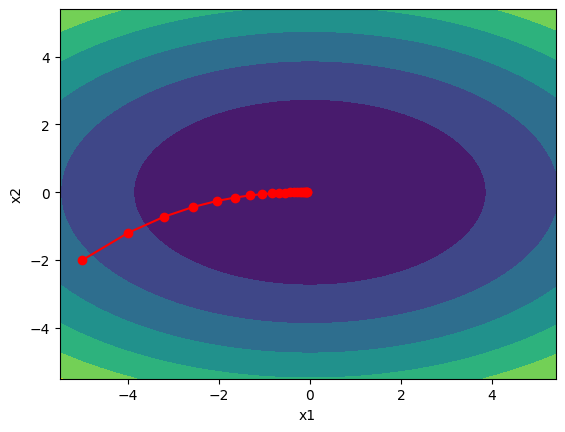

In [82]:
opt = Optimizers("constant", 0.1)
search_path(func, search(opt.gradient_descent, func_grad))

#### 2- SGD (Stochastic Gradient Descent)

epoch 20, x1:-0.0018226196598449124, x2:0.15430778218876876


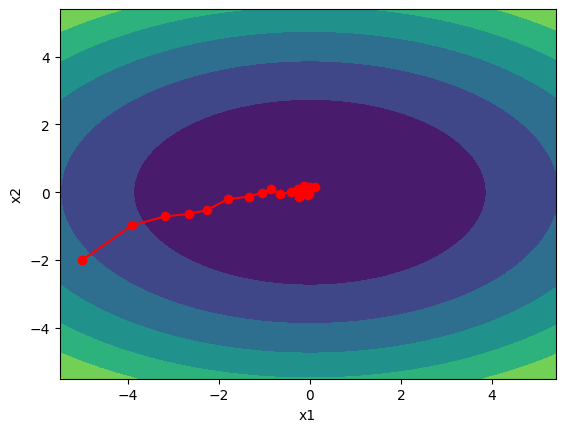

In [83]:
opt = Optimizers("constant", 0.1)
search_path(func, search(opt.stochastic_gradient_descent, func_grad))

#### 3- Gradient Descent with Momentum

epoch 20, x1:1.3779266705610334, x2:-0.5800871623873937


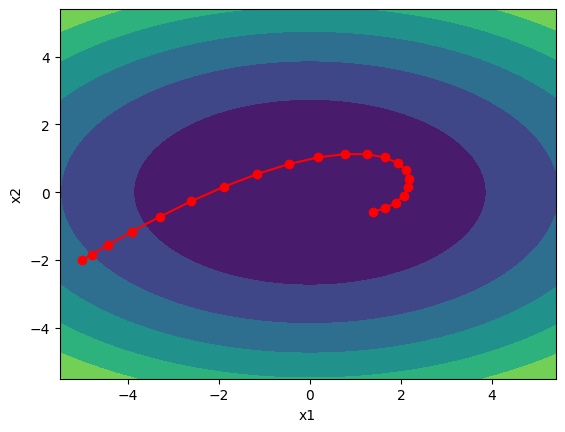

In [84]:
opt = Optimizers("constant", 0.02)
search_path(func, search(opt.gradient_descent_with_momentum, func_grad))

#### 4- Nesterov Gradient Descent with Momentum

epoch 20, x1:-1.1226000420540831, x2:0.00764917525261577


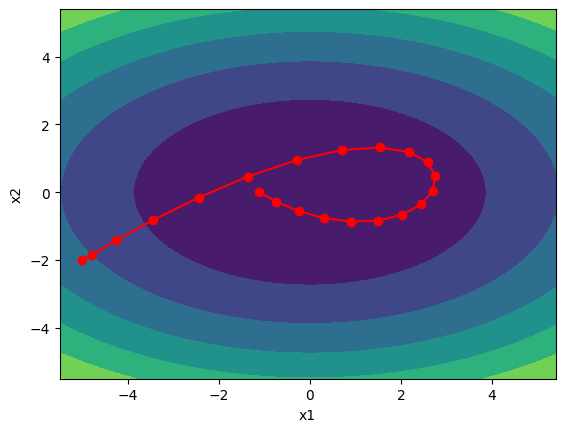

In [85]:
opt = Optimizers("constant", 0.02)
search_path(func, search(opt.nesterov_gradient_descent_with_momentum, func_grad))

#### 5- Adagrad

epoch 20, x1:-1.8828800844526354, x2:-0.05646173745279083


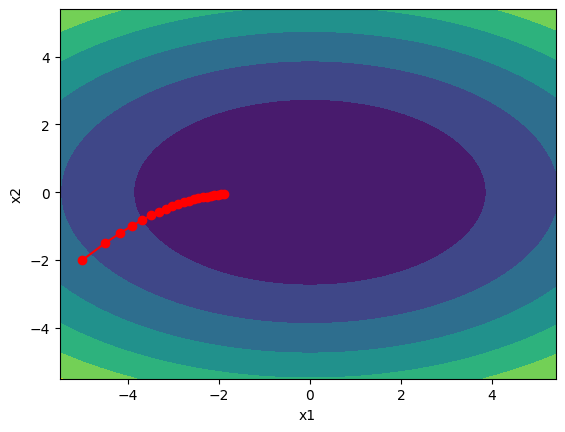

In [86]:
opt = Optimizers("constant", 0.5)
search_path(func, search(opt.ada_grad, func_grad))

#### 6- RMSProp

epoch 20, x1:-0.000343174646715899, x2:6.043535812869311e-14


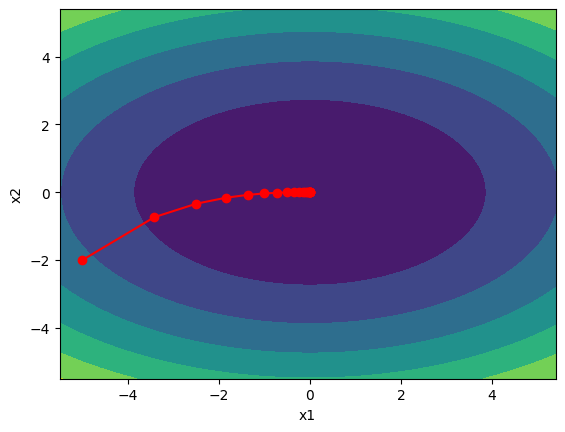

In [87]:
opt = Optimizers("constant", 0.5)
search_path(func, search(opt.rmsprop, func_grad))

#### * AdaGrad vs RMSProp * 

epoch 20, x1:-1.8828800844526354, x2:-0.05646173745279083
epoch 20, x1:-0.000343174646715899, x2:6.043535812869311e-14


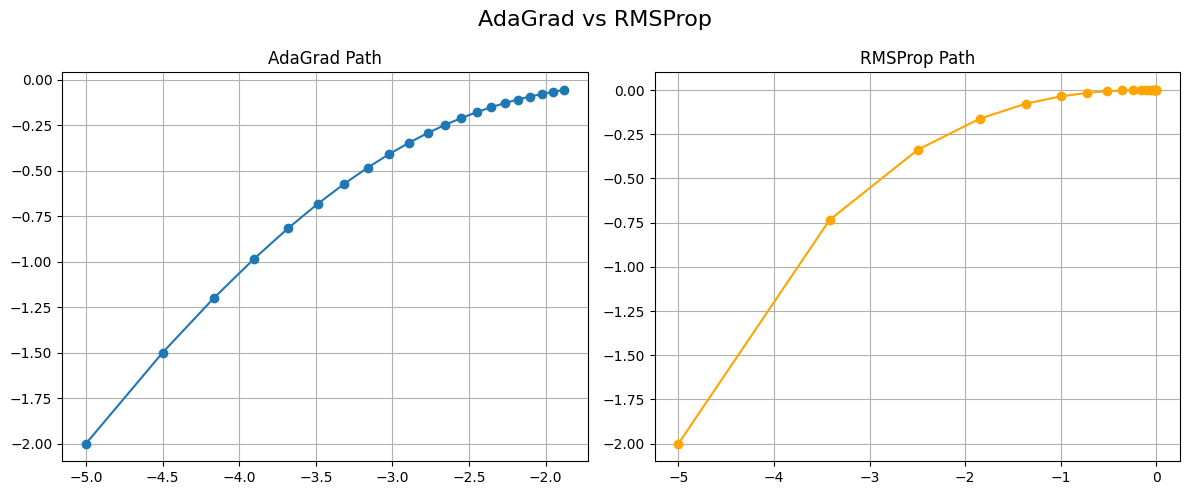

In [88]:
path1 = search(opt.ada_grad, func_grad)
path2 = search(opt.rmsprop, func_grad)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(*zip(*path1), marker='o')
axs[0].set_title("AdaGrad Path")
axs[0].grid(True)

axs[1].plot(*zip(*path2), marker='o', color='orange')
axs[1].set_title("RMSProp Path")
axs[1].grid(True)

fig.suptitle("AdaGrad vs RMSProp", fontsize=16)

plt.tight_layout()
plt.show()

#### 7- RMSProp with Nesterov

epoch 50, x1:0.14092496874038674, x2:0.0192089877448934


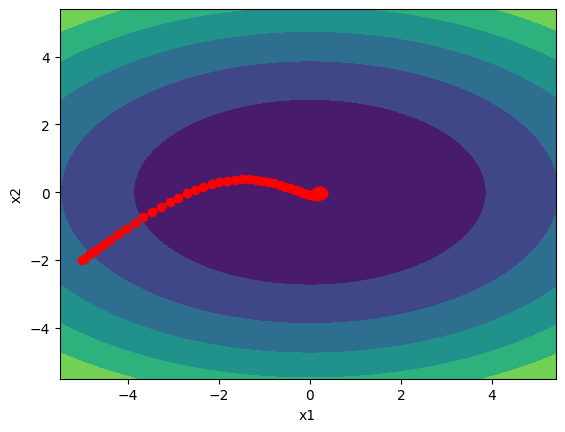

In [89]:
opt = Optimizers("constant", 0.02)
search_path(func, search_rmsprop(opt.rmsprop_with_nesterov, func_grad))

#### 8- Adam

epoch 20, x1:0.09247206594414789, x2:0.27886722324803453


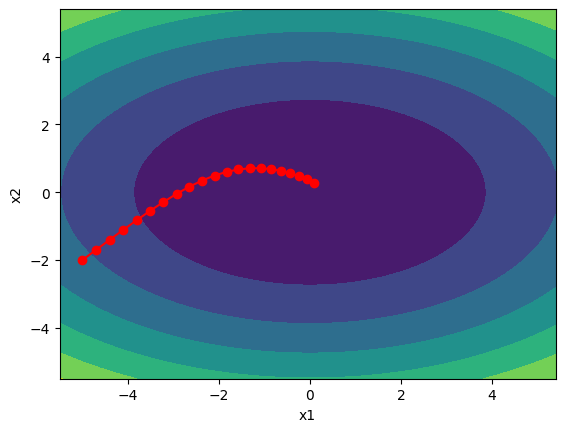

In [90]:
opt = Optimizers("constant", 0.3)
search_path(func, search_adam(opt.adam, func_grad))